In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

dataset=pd.read_csv(r"C:\Users\Asus\Downloads\companies data.csv")
dataset.isnull().sum()
dataset1=dataset

In [10]:
from sklearn.model_selection import train_test_split

x=dataset[['Emp(2018)','Emp(2019)','Emp(2020)','Emp(2021)','Emp(2022)','Emp(2023)','Emp(2024)']]
y=dataset['Emp(2025)']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
from xgboost import XGBRegressor

xgmodel = XGBRegressor()
xgmodel.fit(x_train, y_train)
xgmodel.score(x_test,y_test)

0.999824883051614

In [12]:
pred_2026_list = []

for i in range(len(dataset)):
    
    row = dataset.iloc[i]
    
    input_data = [
        row['Emp(2019)'],
        row['Emp(2020)'],
        row['Emp(2021)'],
        row['Emp(2022)'],
        row['Emp(2023)'],
        row['Emp(2024)'],
        row['Emp(2025)']
    ]
    
    input_array = np.array(input_data, dtype=float).reshape(1, -1)
    
    pred = xgmodel.predict(input_array)[0]
    
    pred_2026_list.append(pred)

dataset['Emp(2026)'] = pred_2026_list
dataset.to_excel("xgmodel(2026).xlsx", index=False)

In [13]:
from sklearn.model_selection import train_test_split

X = dataset1[['Emp(2018)','Emp(2019)','Emp(2020)','Emp(2021)',
              'Emp(2022)','Emp(2023)','Emp(2024)']]

y = dataset1['Emp(2025)']

In [14]:
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_model.score(X_test, y_test)

0.999922550157366

In [15]:
pred_2026_list = []

for i in range(len(dataset1)):
    
    row = dataset1.iloc[i]
    
    input_data = [
        row['Emp(2019)'],
        row['Emp(2020)'],
        row['Emp(2021)'],
        row['Emp(2022)'],
        row['Emp(2023)'],
        row['Emp(2024)'],
        row['Emp(2025)']
    ]

    input_df =np.array(input_data, dtype=float).reshape(1, -1)
    
    pred = lr_model.predict(input_df)[0]
    
    pred_2026_list.append(pred)

dataset1['Emp(2026)_lr'] = pred_2026_list

dataset1.to_excel("lrmodel(2026).xlsx", index=False)

In [19]:
dataset1.isnull().sum()

Company         0
Emp(2018)       0
Emp(2019)       0
Emp(2020)       0
Emp(2021)       0
Emp(2022)       0
Emp(2023)       0
Emp(2024)       0
Emp(2025)       0
Emp(2026)_lr    0
dtype: int64

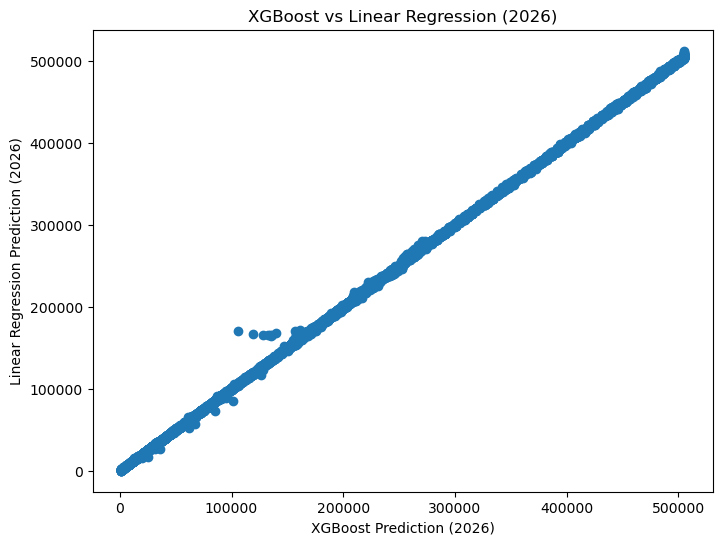

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(dataset['Emp(2026)'], dataset1['Emp(2026)_lr'])

plt.xlabel("XGBoost Prediction (2026)")
plt.ylabel("Linear Regression Prediction (2026)")
plt.title("XGBoost vs Linear Regression (2026)")

plt.show()